In [1]:
import os
import rasterio
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../sample_data"
MODEL_PREDICTIONS = f"{DATA_PATH}/model_predictions"
meta_data = pd.read_excel(f'{DATA_PATH}/V5ModelSummary_CAWA.xlsx', sheet_name=['species', 'regions', 'variables', 'importance', 'validation', 'abundances'])

In [3]:
meta_data.keys()

dict_keys(['species', 'regions', 'variables', 'importance', 'validation', 'abundances'])

In [4]:
files = os.listdir(MODEL_PREDICTIONS)
def extract_species_region_year(files):
    df = pd.DataFrame({"filename": files})

    df[["species", "region", "year"]] = (
        df["filename"]
        .apply(lambda x: Path(x).stem.split("_"))
        .apply(pd.Series)
    )

    df["year"] = df["year"].astype(int)
    df = df.sort_values(by=['species', 'region', 'year'])

    df['data'] = (
        df["filename"]
        .apply(lambda x: rasterio.open(f"{MODEL_PREDICTIONS}/{x}").read())
    )
    return df.set_index("filename")

df = extract_species_region_year(files)
df

,species,region,year,data
filename,,,,
CAWA_Canada_1990.tif,CAWA,Canada,1990,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_1995.tif,CAWA,Canada,1995,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_2000.tif,CAWA,Canada,2000,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_2005.tif,CAWA,Canada,2005,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_2010.tif,CAWA,Canada,2010,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_2015.tif,CAWA,Canada,2015,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Canada_2020.tif,CAWA,Canada,2020,"[[[nan, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Lower48_1990.tif,CAWA,Lower48,1990,"[[[0.0, nan, nan, nan, nan, nan, nan, nan, nan..."
CAWA_Lower48_1995.tif,CAWA,Lower48,1995,"[[[0.0, nan, nan, nan, nan, nan, nan, nan, nan..."


the predictions might be "Time-matched predictors for vegetation biomass, human disturbance, and annual climate"

In [5]:
def plot(data):
    data = data['data']
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    cmaps = ["Reds", "Blues", "Greens"]
    bands = ["var 1", "var 2", "var 3"]
    for band in [0, 1, 2]:
        ax[band].imshow(data[band, :, :], cmap=cmaps[band])
        ax[band].set_title(bands[band])
        ax[band].axis("off")
    plt.tight_layout()
    plt.show()

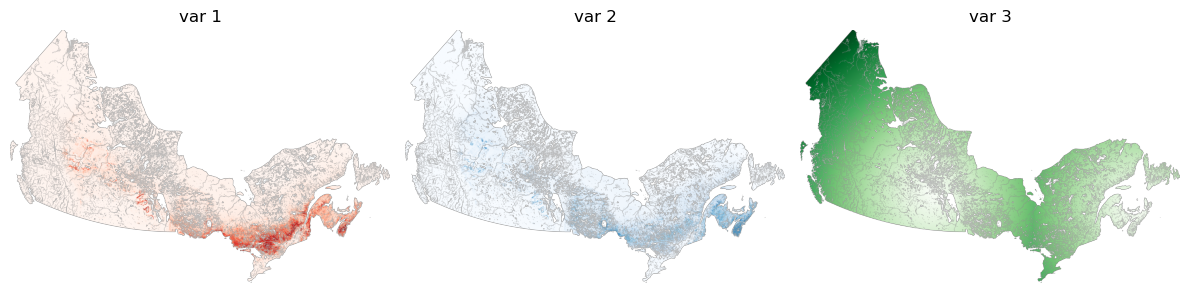

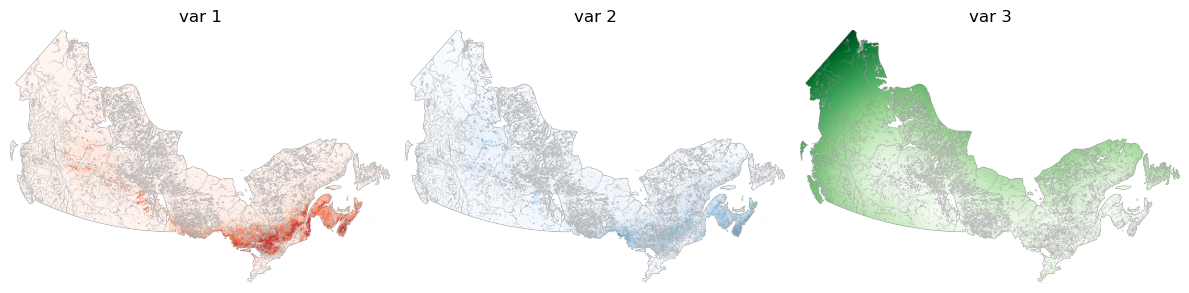

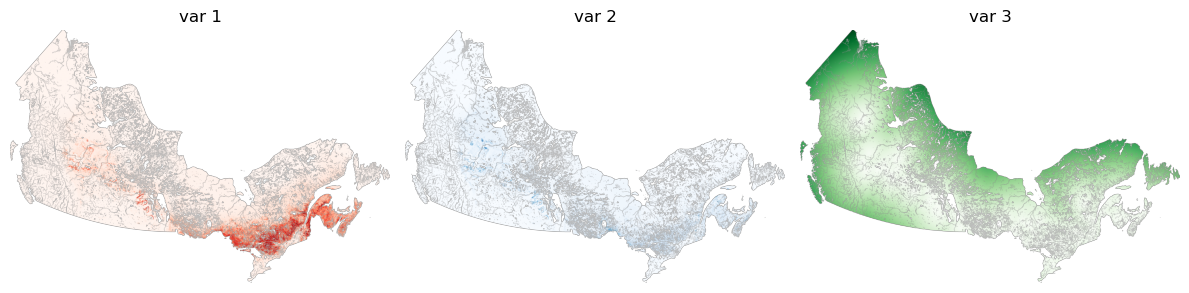

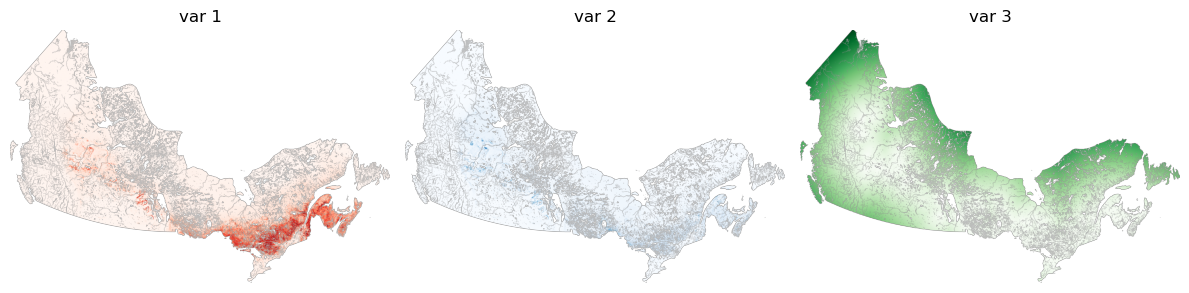

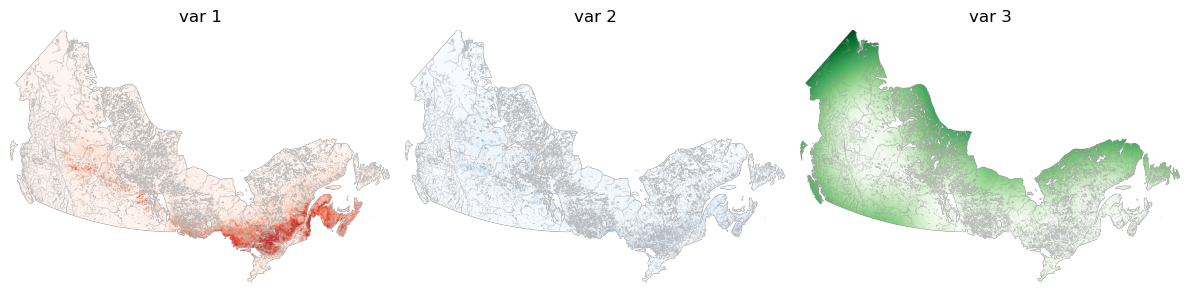

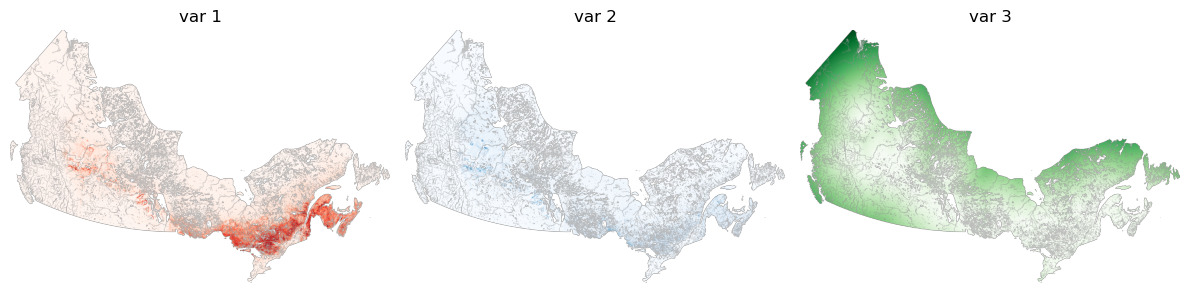

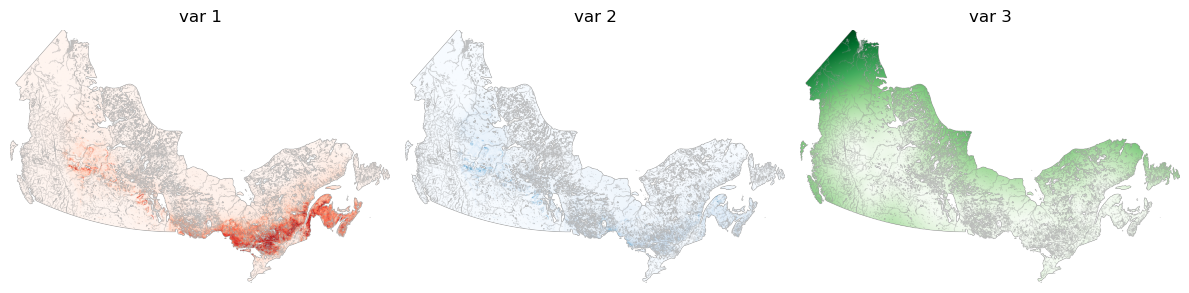

In [6]:
species = 'CAWA'
region = 'Canada'

filtered = df[(df['species'] == species) & (df['region'] == region)]

for y in filtered['year']:
    filename = f"{species}_{region}_{y}.tif"
    plot(df.loc[filename])